##✅ TASK 3: Data Visualization
Goal: Create beautiful, meaningful charts and dashboards.

We'll use the books dataset from Task 1 plus some sales data.

## Step 1 — Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Use books data from Task 1 (or reload it)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

# Also create a small sales dataset for variety
np.random.seed(42)
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
sales_data = pd.DataFrame({
    'Month': months,
    'Sales': [12000,14500,13200,17800,16500,19200,
              21000,20500,18700,22300,25100,28400],
    'Profit': [2400,2900,2640,3560,3300,3840,
               4200,4100,3740,4460,5020,5680],
    'Customers': [320,410,380,520,490,580,
                  640,620,560,680,740,820]
})
print("✅ Data ready!")

✅ Data ready!


##Step 2 — Chart 1: Line Chart (Sales Trend)

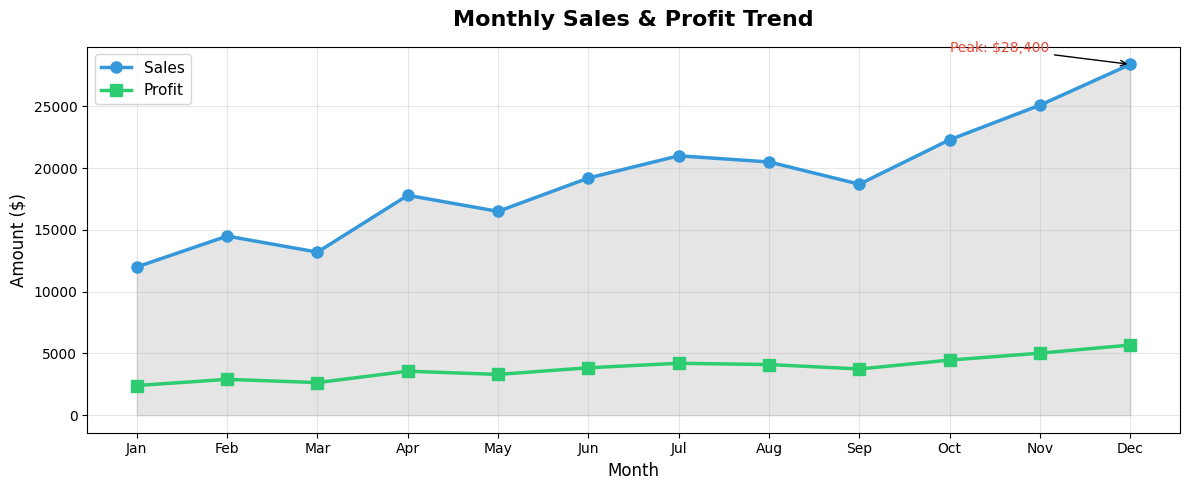

✅ Chart 1 saved!


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sales_data['Month'], sales_data['Sales'],
        marker='o', linewidth=2.5, color='#3498db',
        markersize=8, label='Sales')
ax.plot(sales_data['Month'], sales_data['Profit'],
        marker='s', linewidth=2.5, color='#2ecc71',
        markersize=8, label='Profit')

ax.fill_between(sales_data['Month'], sales_data['Sales'],
                alpha=0.1, color='black')

ax.set_title('Monthly Sales & Profit Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate max
max_idx = sales_data['Sales'].idxmax()
ax.annotate(f"Peak: ${sales_data['Sales'][max_idx]:,}",
            xy=(max_idx, sales_data['Sales'][max_idx]),
            xytext=(max_idx-2, sales_data['Sales'][max_idx]+1000),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='#e74c3c')

plt.tight_layout()
plt.savefig('chart1_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

##Step 3 — Chart 2: Bar Chart (Survival by Class & Gender)


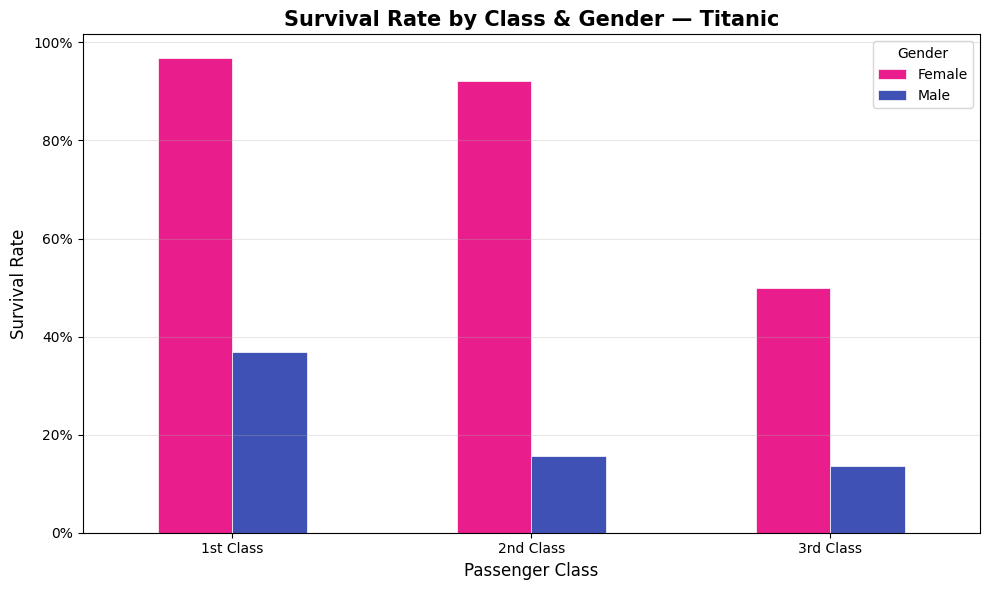

✅ Chart 2 saved!


In [3]:
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['#e91e8c', '#3f51b5'],
           edgecolor='white', linewidth=0.5)

ax.set_title('Survival Rate by Class & Gender — Titanic', fontsize=15, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(['Female', 'Male'], title='Gender')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_bar.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

##Step 4 — Chart 3: Pie Chart (Embarkation Ports)

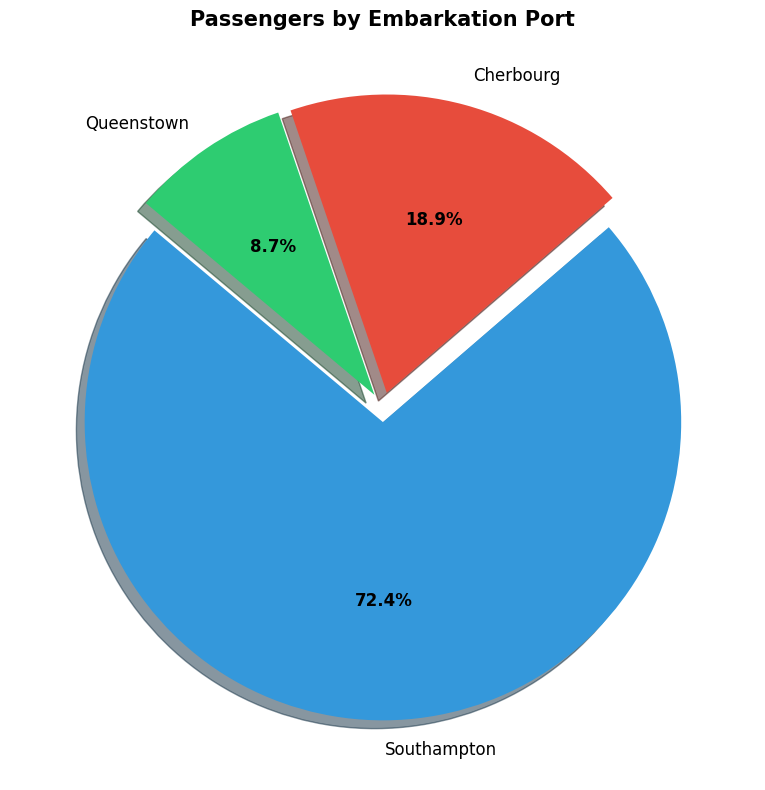

✅ Chart 3 saved!


In [4]:
port_counts = df['Embarked'].value_counts()
port_labels = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
labels = [port_labels.get(p, p) for p in port_counts.index]

colors = ['#3498db', '#e74c3c', '#2ecc71']
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    port_counts, labels=labels, autopct='%1.1f%%',
    colors=colors, explode=explode,
    shadow=True, startangle=140,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Passengers by Embarkation Port', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_pie.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

##Step 5 — Chart 4: Heatmap (Correlation)

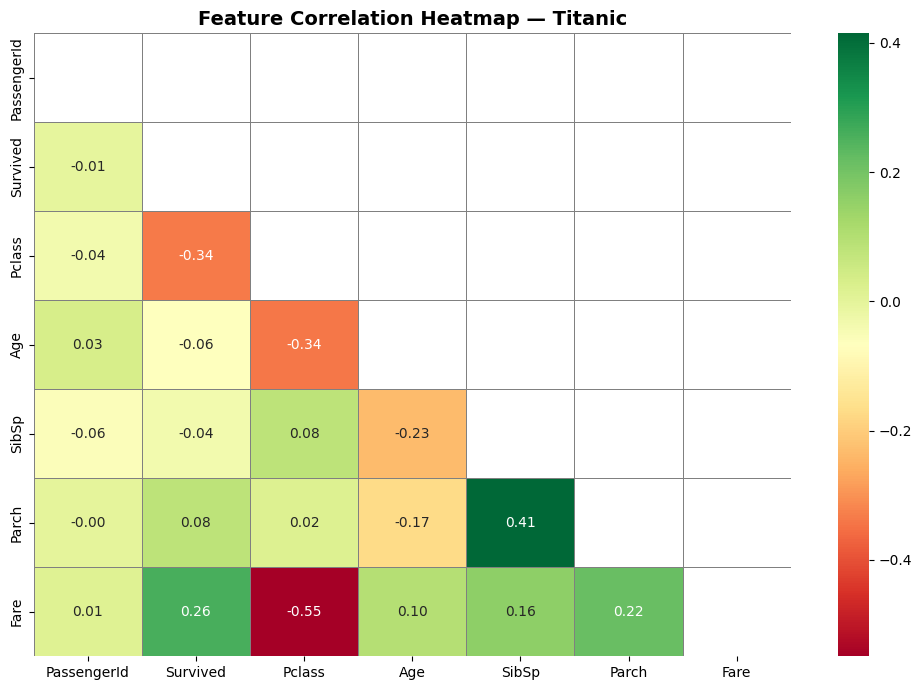

✅ Chart 4 saved!


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_cols = df.select_dtypes(include=[np.number])
mask = np.triu(np.ones_like(numeric_cols.corr(), dtype=bool))

sns.heatmap(numeric_cols.corr(),
            annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 10})

ax.set_title('Feature Correlation Heatmap — Titanic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

##Step 6 — Chart 5: Interactive Plotly Dashboard

In [6]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Age Distribution by Survival',
        'Fare vs Age (by Survival)',
        'Monthly Sales Trend',
        'Passengers by Class'
    )
)

# Plot 1: Age histogram
for survived, color, name in [(0,'#e74c3c','Did Not Survive'),
                               (1,'#2ecc71','Survived')]:
    subset = df[df['Survived']==survived]
    fig.add_trace(go.Histogram(x=subset['Age'], name=name,
                               marker_color=color, opacity=0.7,
                               nbinsx=25), row=1, col=1)

# Plot 2: Scatter
colors_map = df['Survived'].map({0:'#e74c3c', 1:'#2ecc71'})
fig.add_trace(go.Scatter(x=df['Age'], y=df['Fare'],
                          mode='markers',
                          marker=dict(color=colors_map, size=5, opacity=0.6),
                          name='Fare vs Age'), row=1, col=2)

# Plot 3: Sales line
fig.add_trace(go.Scatter(x=sales_data['Month'], y=sales_data['Sales'],
                          mode='lines+markers', name='Sales',
                          line=dict(color='#3498db', width=3)), row=2, col=1)

# Plot 4: Class bar
class_counts = df['Pclass'].value_counts().sort_index()
fig.add_trace(go.Bar(x=['1st','2nd','3rd'], y=class_counts.values,
                      marker_color=['gold','silver','#3498db'],
                      name='Passengers'), row=2, col=2)

fig.update_layout(
    title_text='📊 Interactive Data Visualization Dashboard',
    title_font_size=18,
    height=700,
    showlegend=False,
    template='plotly_dark'
)

fig.write_html('interactive_dashboard.html')
fig.show()
print("✅ Interactive dashboard saved!")

✅ Interactive dashboard saved!
